## Imports & Configurations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

star_colors = np.load(os.path.join(os.getcwd(), '..', 'Outputs', 'star_colors.npz'))
r_i_clean_star = star_colors['r_i_clean_star']
g_r_clean_star = star_colors['g_r_clean_star']
u_g_clean_star = star_colors['u_g_clean_star']
i_z_clean_star = star_colors['i_z_clean_star']

qso_colors = np.load(os.path.join(os.getcwd(), '..', 'Outputs', 'quasar_colors.npz'))
r_i_clean_qso = qso_colors['r_i_clean_qso']
g_r_clean_qso = qso_colors['g_r_clean_qso']
u_g_clean_qso = qso_colors['u_g_clean_qso']
i_z_clean_qso = qso_colors['i_z_clean_qso']
Z = qso_colors['Z']

## Redshift Intervals

In [2]:
z_bins = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0])
z_labels = ['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '3.0-4.0']
z_mid = (z_bins[:-1] + z_bins[1:]) / 2
z_masks = []

for i, (low, high) in enumerate(zip(z_bins[:-1], z_bins[1:])):
    if i == 0:
        mask = (Z >= low) & (Z <= high)
    else:
        mask = (Z > low) & (Z <= high)

    z_masks.append(mask)

## Grid Size Definition

In [3]:
n_grid = 200
x_range, y_range = (-2, 4), (-2, 4)

projections = [
    (r_i_clean_star, g_r_clean_star, r_i_clean_qso, g_r_clean_qso, 'r-i', 'g-r'),
    (u_g_clean_star, g_r_clean_star, u_g_clean_qso, g_r_clean_qso, 'u-g', 'g-r'),
    (r_i_clean_star, i_z_clean_star, r_i_clean_qso, i_z_clean_qso, 'r-i', 'i-z'),
    (u_g_clean_star, r_i_clean_star, u_g_clean_qso, r_i_clean_qso, 'u-g', 'r-i'),
]

for sx, sy, qx, qy, xlab, ylab in projections:
    H, xedges, yedges = np.histogram2d(sx, sy, bins=n_grid, range=[x_range, y_range])
    print(f'--- {xlab} vs {ylab} ---')
    print('Max cell count:', H.max())
    print('Mean (nonzero cells):', H[H > 0].mean())
    print('Percentiles (nonzero cells):', np.percentile(H[H > 0], [10, 25, 50, 75, 90]))
    print('Number of nonzero cells:', np.count_nonzero(H))
    print()

--- r-i vs g-r ---
Max cell count: 46820.0
Mean (nonzero cells): 336.25445876743777
Percentiles (nonzero cells): [  1.    2.    4.   17.  186.8]
Number of nonzero cells: 5663

--- u-g vs g-r ---
Max cell count: 13654.0
Mean (nonzero cells): 356.32559880239523
Percentiles (nonzero cells): [  1.    2.    7.   80.  805.1]
Number of nonzero cells: 5344

--- r-i vs i-z ---
Max cell count: 86989.0
Mean (nonzero cells): 356.72648932184336
Percentiles (nonzero cells): [ 1.  1.  3. 12. 82.]
Number of nonzero cells: 5338

--- u-g vs r-i ---
Max cell count: 18855.0
Mean (nonzero cells): 207.1137698499021
Percentiles (nonzero cells): [  1.    1.    4.   16.  170.7]
Number of nonzero cells: 9194



## Color-Space Quasars Outside Grid

In [4]:
boundary_results = []

retention_sample = (Z >= z_bins[0]) & (Z <= z_bins[-1])

for sx, sy, qx, qy, xlab, ylab in projections:

    inside = (
        np.isfinite(qx) & np.isfinite(qy) &
        (qx >= x_range[0]) & (qx <= x_range[1]) &
        (qy >= y_range[0]) & (qy <= y_range[1])
    )

    n_total = np.count_nonzero(retention_sample)
    n_inside = np.count_nonzero(inside & retention_sample)
    n_outside = np.count_nonzero(~inside & retention_sample)

    pct_inside = 100 * n_inside / n_total
    pct_outside = 100 * n_outside / n_total

    row = {
        'projection': f'({xlab}) and ({ylab})',
        'x': xlab,
        'y': ylab,
        'x_range': f'[{x_range[0]}, {x_range[1]}]',
        'y_range': f'[{y_range[0]}, {y_range[1]}]',
        'n_total': n_total,
        'n_inside': n_inside,
        'n_outside': n_outside,
        'pct_inside': pct_inside,
        'pct_outside': pct_outside,
    }

    boundary_results.append(row)

    print(f'\n({xlab}) and ({ylab})')
    print(f'Quasars inside grid: {n_inside:,} / {n_total:,} ({pct_inside:.3f}%)')
    print(f'Quasars outside grid: {n_outside:,} / {n_total:,} ({pct_outside:.3f}%)')

boundary_df = pd.DataFrame(boundary_results)
output_path = os.path.join(os.getcwd(), '..', 'Outputs', 'Grid_Boundary_Outside_Counts.csv')
boundary_df.to_csv(output_path, index=False)
boundary_df


(r-i) and (g-r)
Quasars inside grid: 162,855 / 162,856 (99.999%)
Quasars outside grid: 1 / 162,856 (0.001%)

(u-g) and (g-r)
Quasars inside grid: 162,856 / 162,856 (100.000%)
Quasars outside grid: 0 / 162,856 (0.000%)

(r-i) and (i-z)
Quasars inside grid: 162,855 / 162,856 (99.999%)
Quasars outside grid: 1 / 162,856 (0.001%)

(u-g) and (r-i)
Quasars inside grid: 162,855 / 162,856 (99.999%)
Quasars outside grid: 1 / 162,856 (0.001%)


,projection,x,y,x_range,y_range,n_total,n_inside,n_outside,pct_inside,pct_outside
0,(r-i) and (g-r),r-i,g-r,"[-2, 4]","[-2, 4]",162856,162855,1,99.999386,0.000614
1,(u-g) and (g-r),u-g,g-r,"[-2, 4]","[-2, 4]",162856,162856,0,100.000000,0.000000
2,(r-i) and (i-z),r-i,i-z,"[-2, 4]","[-2, 4]",162856,162855,1,99.999386,0.000614
3,(u-g) and (r-i),u-g,r-i,"[-2, 4]","[-2, 4]",162856,162855,1,99.999386,0.000614


## Testing Different Grid Sizes & Thresholds

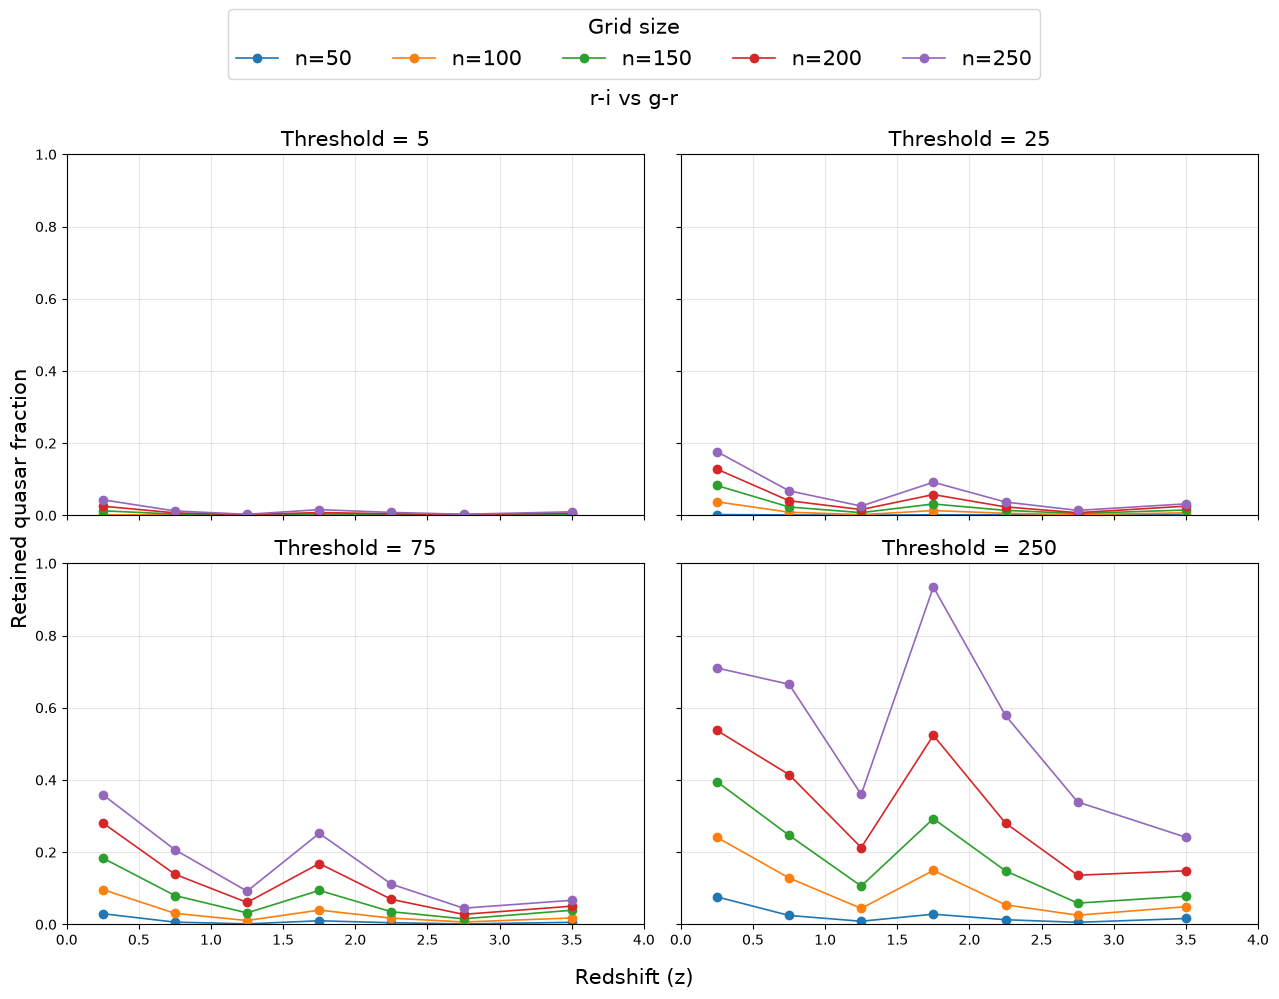

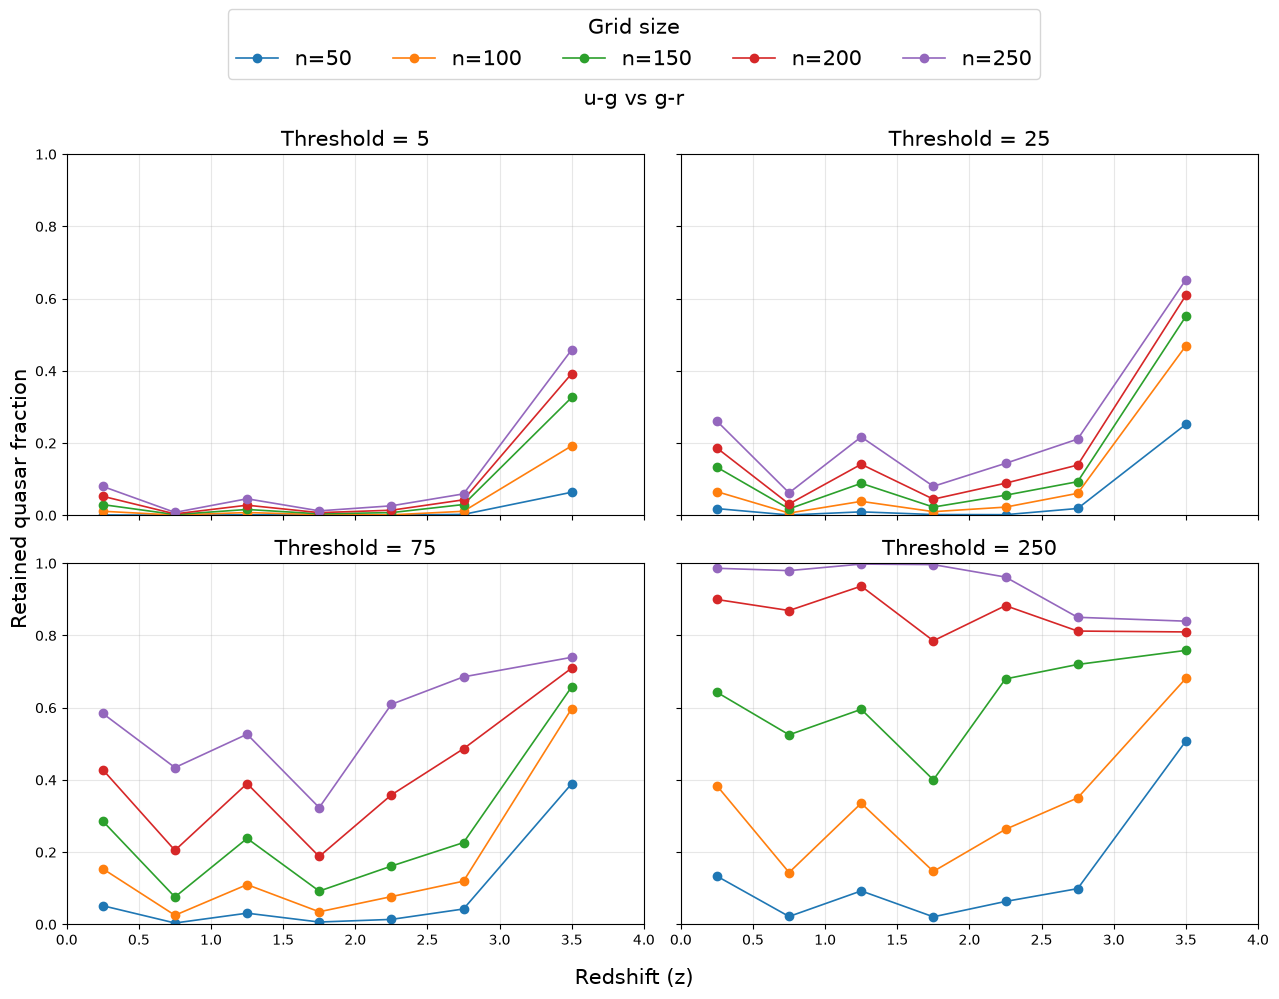

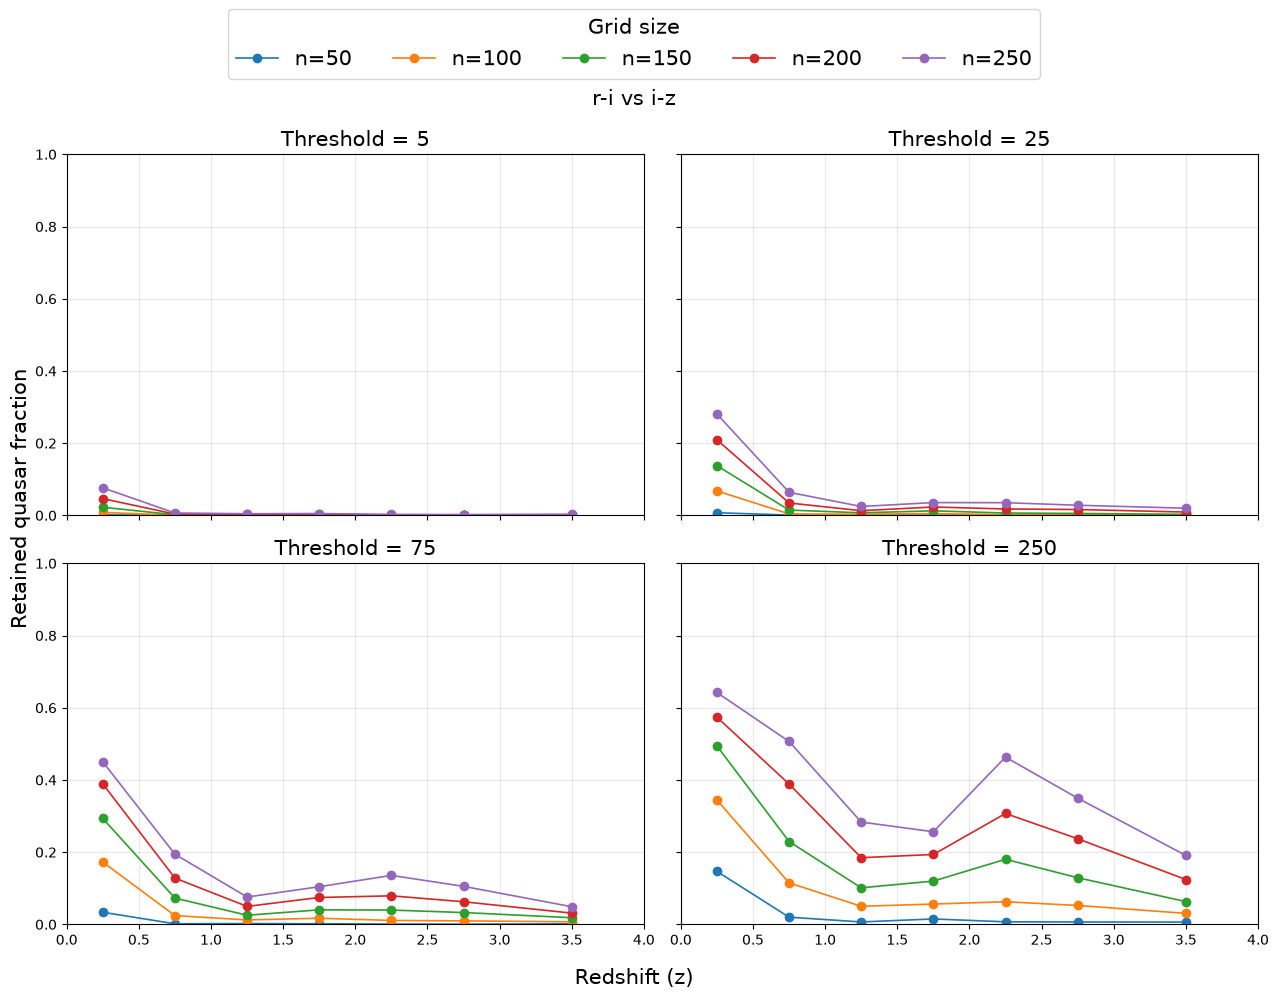

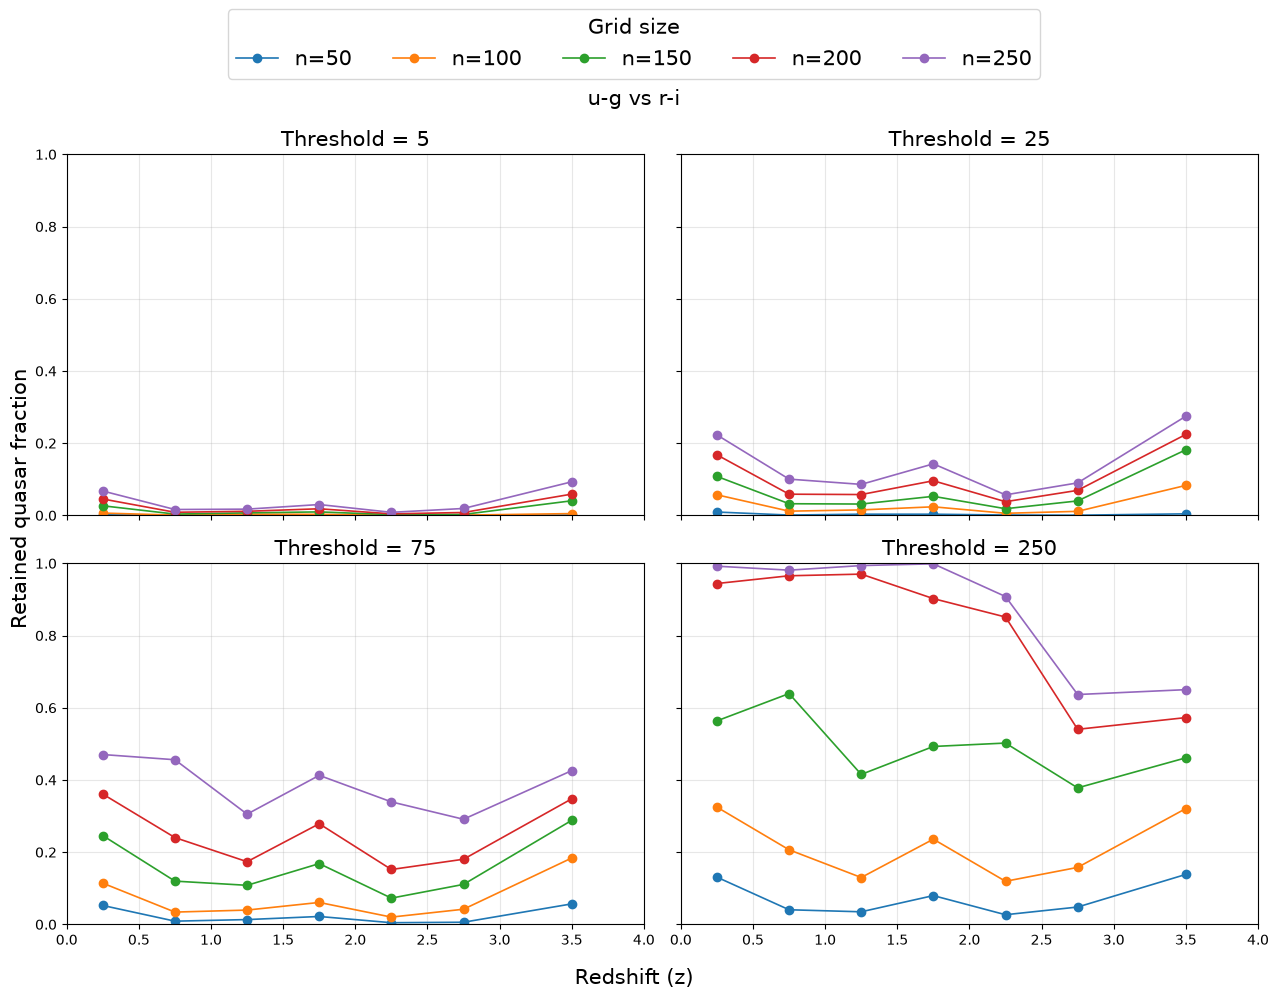

In [5]:
grid_sizes = [50, 100, 150, 200, 250]
thresholds = [5, 25, 75, 250]
x_range, y_range = (-2, 4), (-2, 4)

sensitivity_results = []

for sx, sy, qx, qy, xlab, ylab in projections:
    proj_label = f'{xlab} vs {ylab}'
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, threshold in zip(axes, thresholds):
        for n_grid_test in grid_sizes:
            H_star, xedges, yedges = np.histogram2d(sx, sy, bins=n_grid_test, range=[x_range, y_range])

            xbin = np.searchsorted(xedges, qx, side='right') - 1
            ybin = np.searchsorted(yedges, qy, side='right') - 1

            inside = (
                np.isfinite(qx) & np.isfinite(qy) &
                (qx >= xedges[0]) & (qx <= xedges[-1]) &
                (qy >= yedges[0]) & (qy <= yedges[-1])
            )

            xbin = np.clip(xbin, 0, n_grid_test - 1)
            ybin = np.clip(ybin, 0, n_grid_test - 1)

            stellar_density = np.zeros(len(qx), dtype=float)
            stellar_density[inside] = H_star[xbin[inside], ybin[inside]]

            outside_locus = (~inside) | (stellar_density < threshold)

            fractions = []
            for i, zmask in enumerate(z_masks):
                n_bin = np.count_nonzero(zmask)
                n_retained_bin = np.count_nonzero(outside_locus & zmask)
                frac = n_retained_bin / n_bin if n_bin > 0 else np.nan
                fractions.append(frac)

                sensitivity_results.append({
                    'projection': proj_label,
                    'threshold': threshold,
                    'n_grid': n_grid_test,
                    'redshift_bin': z_labels[i],
                    'z_mid': z_mid[i],
                    'N': n_bin,
                    'N_retained': n_retained_bin,
                    'retained_fraction': frac
                })

            ax.plot(z_mid, fractions, marker='o', linewidth=1.2, label=f'n={n_grid_test}')

        ax.set_title(f'Threshold = {threshold}', fontsize=15)
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 4)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    legend = fig.legend(handles, labels_leg, title='Grid size', loc='upper center',
               bbox_to_anchor=(0.5, 1), ncol=5, fontsize=15)
    legend.get_title().set_fontsize(15)
    fig.suptitle(proj_label, fontsize=15, y=0.91)
    fig.supxlabel('Redshift (z)', fontsize=15)
    fig.supylabel('Retained quasar fraction', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

## Export Sensitivity

In [6]:
sensitivity_df = pd.DataFrame(sensitivity_results)
output_path = os.path.join(os.getcwd(), '..', 'Outputs', 'Grid_Size_Threshold_Sensitivity.csv')
sensitivity_df.to_csv(output_path, index=False)

sensitivity_df

,projection,threshold,n_grid,redshift_bin,z_mid,N,N_retained,retained_fraction
0,r-i vs g-r,5,50,0-0.5,0.25,7332,6,0.000818
1,r-i vs g-r,5,50,0.5-1.0,0.75,31255,15,0.000480
2,r-i vs g-r,5,50,1.0-1.5,1.25,32773,10,0.000305
3,r-i vs g-r,5,50,1.5-2.0,1.75,35690,23,0.000644
4,r-i vs g-r,5,50,2.0-2.5,2.25,39766,22,0.000553
...,...,...,...,...,...,...,...,...
555,u-g vs r-i,250,250,1.0-1.5,1.25,32773,32570,0.993806
556,u-g vs r-i,250,250,1.5-2.0,1.75,35690,35641,0.998627
557,u-g vs r-i,250,250,2.0-2.5,2.25,39766,36110,0.908062
558,u-g vs r-i,250,250,2.5-3.0,2.75,14631,9315,0.636662


## Bootstrap Resampling

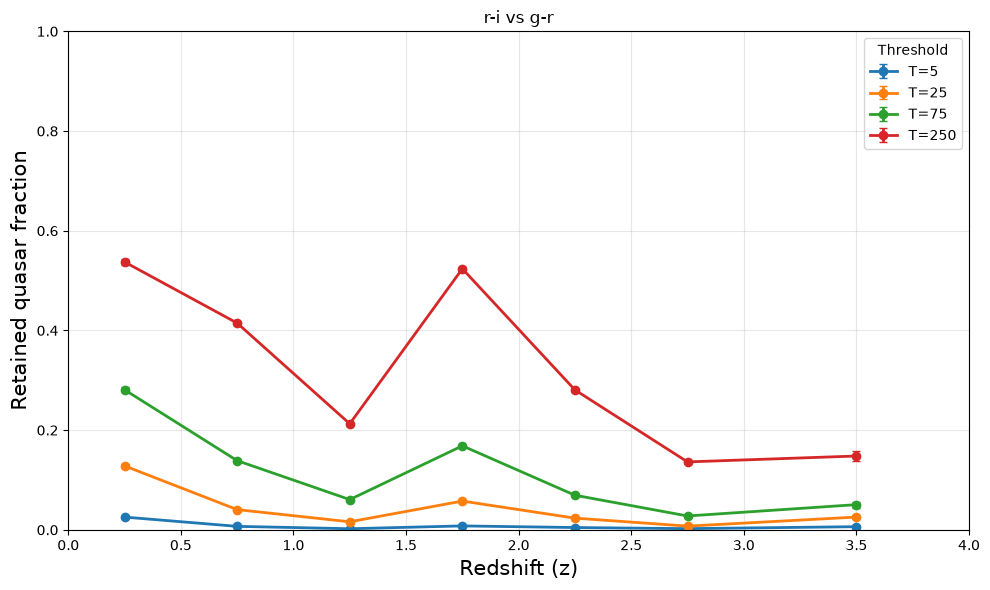

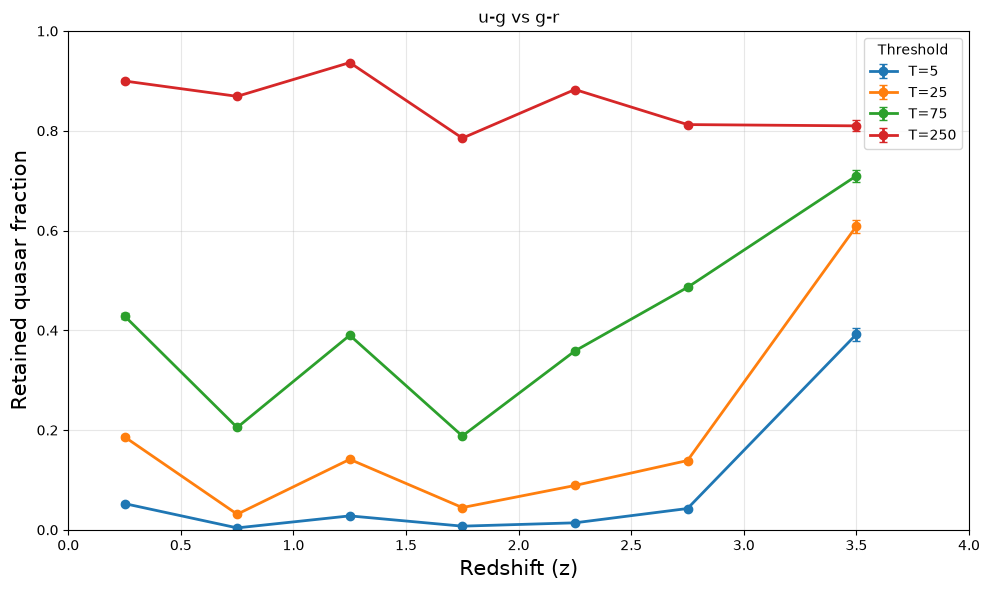

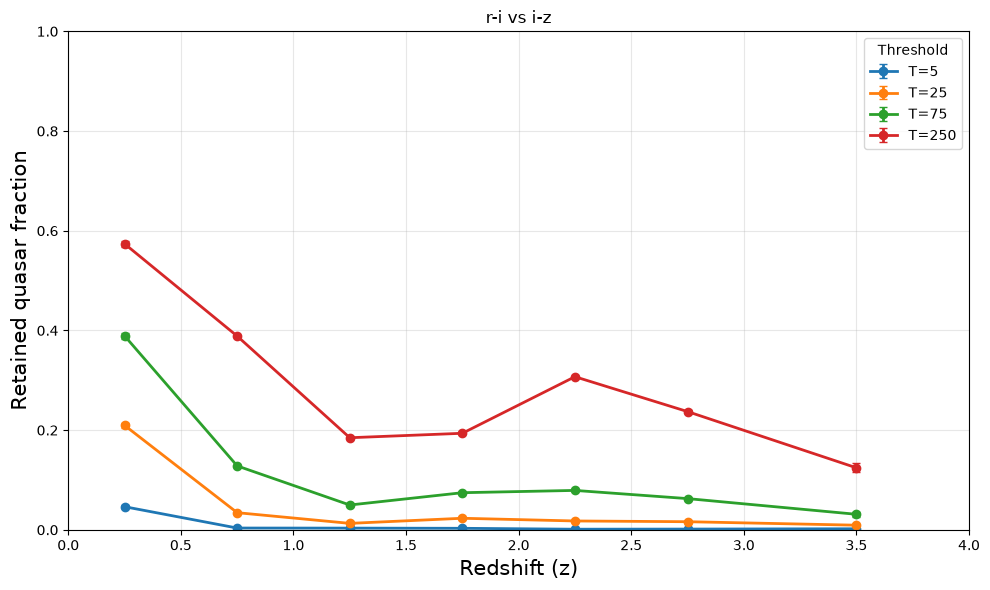

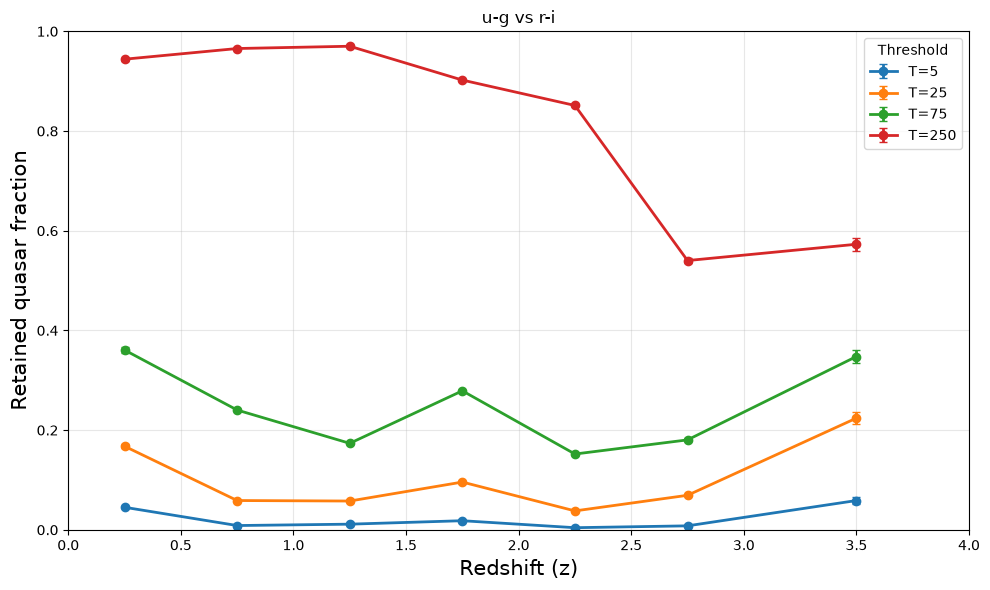

,projection,threshold,n_grid,redshift_bin,z_mid,N,bootstrap_mean,bootstrap_std
0,r-i vs g-r,5,200,0-0.5,0.25,7332,0.025561,0.001895
1,r-i vs g-r,5,200,0.5-1.0,0.75,31255,0.006972,0.000463
2,r-i vs g-r,5,200,1.0-1.5,1.25,32773,0.002193,0.000259
3,r-i vs g-r,5,200,1.5-2.0,1.75,35690,0.007862,0.000472
4,r-i vs g-r,5,200,2.0-2.5,2.25,39766,0.004593,0.000344
...,...,...,...,...,...,...,...,...
107,u-g vs r-i,250,200,1.0-1.5,1.25,32773,0.970108,0.000907
108,u-g vs r-i,250,200,1.5-2.0,1.75,35690,0.902233,0.001543
109,u-g vs r-i,250,200,2.0-2.5,2.25,39766,0.851287,0.001814
110,u-g vs r-i,250,200,2.5-3.0,2.75,14631,0.540167,0.004222


In [9]:
n_grid_final = 200
thresholds = [5, 25, 75, 250]
n_bootstrap = 1000

bootstrap_results = []

for sx, sy, qx, qy, xlab, ylab in projections:

    proj_label = f'{xlab} vs {ylab}'

    H_star, xedges, yedges = np.histogram2d(
        sx, sy,
        bins=n_grid_final,
        range=[x_range, y_range]
    )

    xbin = np.searchsorted(xedges, qx, side='right') - 1
    ybin = np.searchsorted(yedges, qy, side='right') - 1

    inside = (
        np.isfinite(qx) & np.isfinite(qy) &
        (qx >= xedges[0]) & (qx <= xedges[-1]) &
        (qy >= yedges[0]) & (qy <= yedges[-1])
    )

    xbin = np.clip(xbin, 0, n_grid_final - 1)
    ybin = np.clip(ybin, 0, n_grid_final - 1)

    stellar_density = np.zeros(len(qx), dtype=float)
    stellar_density[inside] = H_star[xbin[inside], ybin[inside]]

    fig, ax = plt.subplots(figsize=(10, 6))

    for threshold in thresholds:

        outside_locus = (~inside) | (stellar_density < threshold)

        boot_fractions_per_bin = [
            [] for _ in range(len(z_bins) - 1)
        ]

        for i, zmask in enumerate(z_masks):

            bin_indices = np.where(zmask)[0]
            n_bin = len(bin_indices)

            if n_bin == 0:
                continue

            retained_status = outside_locus[bin_indices]

            for _ in range(n_bootstrap):

                resampled_status = np.random.choice(
                    retained_status,
                    size=n_bin,
                    replace=True
                )

                frac = np.mean(resampled_status)

                boot_fractions_per_bin[i].append(frac)

        boot_means = []
        boot_stds = []

        for b in boot_fractions_per_bin:

            if len(b) > 0:
                boot_means.append(np.mean(b))
                boot_stds.append(np.std(b, ddof=1))
            else:
                boot_means.append(np.nan)
                boot_stds.append(np.nan)

        for i in range(len(z_bins) - 1):

            bootstrap_results.append({
                'projection': proj_label,
                'threshold': threshold,
                'n_grid': n_grid_final,
                'redshift_bin': z_labels[i],
                'z_mid': z_mid[i],
                'N': len(np.where(z_masks[i])[0]),
                'bootstrap_mean': boot_means[i],
                'bootstrap_std': boot_stds[i]
            })

        # Plot
        ax.errorbar(
            z_mid,
            boot_means,
            yerr=boot_stds,
            marker='o',
            linewidth=2,
            capsize=3,
            label=f'T={threshold}'
        )

    ax.set_xlabel('Redshift (z)', fontsize=15)
    ax.set_ylabel('Retained quasar fraction', fontsize=15)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 4)
    ax.grid(alpha=0.3)
    ax.legend(title='Threshold')
    ax.set_title(f'{proj_label}')

    plt.tight_layout()
    plt.show()


bootstrap_df = pd.DataFrame(bootstrap_results)

output_path = os.path.join(
    os.getcwd(),
    '..',
    'Outputs',
    'Bootstrap_Retention.csv'
)

bootstrap_df.to_csv(output_path, index=False)

bootstrap_df